# 常见策略Alpha/Strategy/Schemes

- 技术分析交易Technical Analysis
- PER(Price-to-Earning Ratio)市盈率 
- DDM(Dividend Discount Model)股息折扣模型 - 利用企业指标进行行业分析 Analysis of sector using corporate indicateurs
  
价格预测
- 随机森林
- K-Nearest Neighbors (KNN) 
- DBSCAN (Density-Based Spatial Clustering of Applications with Noise)基于密度的聚类方法



- Value at Risk (VaR)风险价值 - "What is the worst loss I can expect with X% confidence?"
- Expected Shortfall(ES)预期损失or缺口 - "If I do experience a loss beyond that, what's the average loss I can expect?"
- Stress test压力测试模拟

## Momentum

<img src="https://raw.githubusercontent.com/tomctang/NB_img/main/momentum.png" alt="C" width="700">


In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Function to calculate momentum return during h look_back periode
def calculate_momentum(prices, lookback_period):
    momentum = prices.pct_change(lookback_period)
    return momentum

# Constants
LOOKBACK_PERIOD = 63  # Approximately 3 months of trading days for 2 years of période
REBALANCE_FREQ = '1D'  # Daily rebalancing

# Use calculate_momentum -> long/short signals -> plotting
def momentum_strategy(ticker, start_date, end_date):
    # Download data and select the 'Close' column, which is already a DataFrame
    data = yf.download(ticker, start=start_date, end=end_date)[['Close']]
    data = data.rename(columns={'Close': ticker})

    # momentum calculation
    momentum_scores = calculate_momentum(data, LOOKBACK_PERIOD)

    # Initialisation of long and short signals
    long_signals = pd.DataFrame(False, index=data.index, columns=[ticker])
    short_signals = pd.DataFrame(False, index=data.index, columns=[ticker])

    # Matching momentum scores index and long ans short signals index
    aligned_momentum_scores = momentum_scores.reindex(data.index)

    for date in aligned_momentum_scores.index:
        today_momentum = aligned_momentum_scores.loc[date, ticker]
        if isinstance(today_momentum, pd.Series):
            today_momentum = today_momentum.iloc[0]  # take the first value if multiple
        long_signals.at[date, ticker] = today_momentum > 0
        short_signals.at[date, ticker] = today_momentum <= 0

    # Filter signals daily frequency and fill daily signals : 
    # ex : if we have a long signal, we fill all daily signals by long until the next short signal 
    long_signals = long_signals.resample(REBALANCE_FREQ).ffill().astype(bool)
    short_signals = short_signals.resample(REBALANCE_FREQ).ffill().astype(bool)

    # Plotting the signals
    plt.figure(figsize=(15, 7))
    plt.plot(data, label=f'{ticker} Price')
    plt.plot(data[long_signals[ticker]], '^', color='g', markersize=10, label='Long Signal')
    plt.plot(data[short_signals[ticker]], 'v', color='r', markersize=10, label='Short Signal')
    plt.title(f'{ticker} Momentum Signals')
    plt.legend()
    plt.show()

    return long_signals, short_signals, data

# get long-to-short signal ratio for selected period
def rank_asset(ticker, long_signals, short_signals, start_date, end_date):
    # Count the number of long and short signals within the period
    nb_long_signals = long_signals.loc[start_date:end_date, ticker].sum()
    nb_short_signals = short_signals.loc[start_date:end_date, ticker].sum()
    # Avoid division by zero
    if nb_short_signals == 0:
        ratio = float('inf')  # Assign infinity if no short signals
    else:
        ratio = nb_long_signals / nb_short_signals

    return ratio

# 如果算法检测到 3 个连续的多(空)头信号，我们就进入买入(清算)仓位
def execution_momentum_strategy(ticker, start_date, end_date):
    long_signals, short_signals, data = momentum_strategy(ticker, start_date, end_date)
    in_position = False
    entry_price = 0
    total_return = 0
    entry_date = []
    exit_date = []
    entry_price_list = []
    strategy_retrace_price=[]

    # Adjust end_date to the closest available date in data if it's not present
    end_date = pd.to_datetime(end_date)
    if end_date not in data.index:
        end_date = data.index[data.index < end_date][-1]

    # Create rolling series for signals
    rolling_long_signals = long_signals[ticker].rolling(window=3).sum()
    rolling_short_signals = short_signals[ticker].rolling(window=3).sum()

    for date in data.index:
        if not in_position and rolling_long_signals.loc[date] == 3:
            entry_price = float(data.loc[date, ticker])
            entry_price_list.append(entry_price)
            strategy_retrace_price.append(entry_price)
            entry_date.append(date)
            in_position = True
        elif in_position and (rolling_short_signals.loc[date] == 3 or date == end_date):
            exit_price = float(data.loc[date, ticker])
            total_return += (exit_price - entry_price)
            exit_date.append(date)
            strategy_retrace_price.append(exit_price)
            in_position = False

    total_return_percent = ((total_return / entry_price_list[0]) * 100) if entry_price_list else 0
    strategy_retrace_price = pd.Series(strategy_retrace_price)

    return total_return_percent, entry_date, exit_date, strategy_retrace_price

# execution_momentum_strategy 计算最终回报
def momentun_strategy_traing_final(tickers, start_date, end_date):
    for ticker in tickers:
        total_return,entry_date,exit_date, strategy_retrace_price= execution_momentum_strategy(ticker, start_date, end_date)
        print(f"Total Return Rate: {total_return:.2f} %")
        print(f"Entry Dates are: {entry_date}")
        print(f"Exit Dates are: {exit_date}")

    return execution_momentum_strategy(ticker, start_date, end_date)


In [1]:
numbers = [1, 2, 3, 4]
total = sum(numbers)
print(total)

10


/tmp/ipykernel_6844/3720828892.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)[['Close']]
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_6844/3720828892.py:45: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.plot(data[long_signals[ticker]], '^', color='g', markersize=10, label='Long Signal')
/tmp/ipykernel_6844/3720828892.py:46: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.plot(data[short_signals[ticker]], 'v', color='r', markersize=10, label='Short Signal')


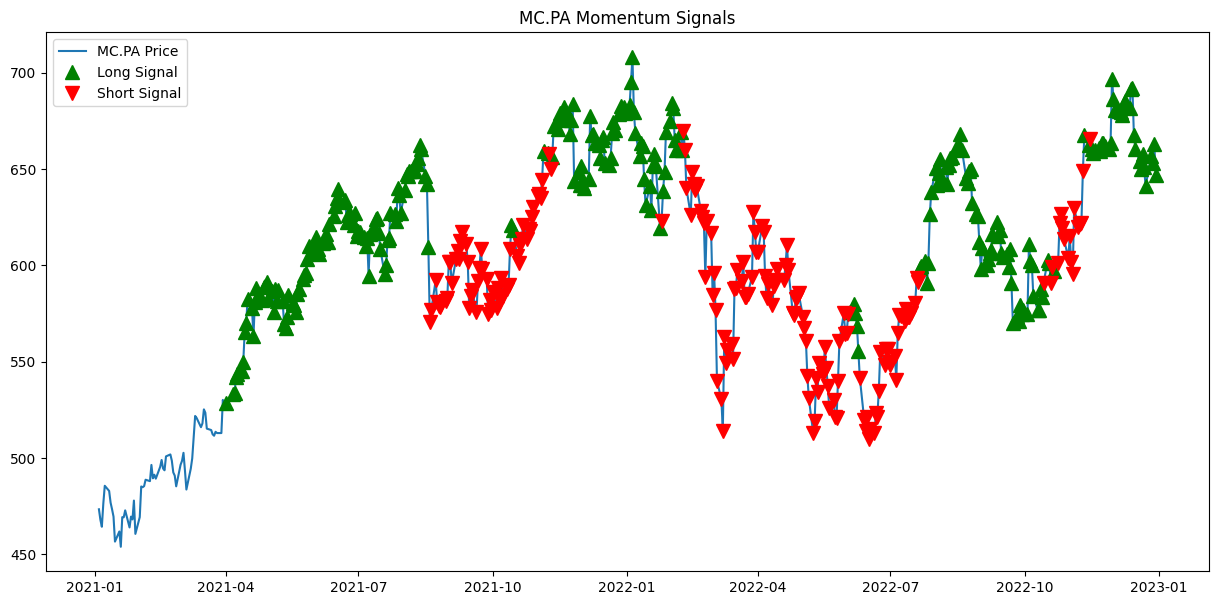

/tmp/ipykernel_6844/3720828892.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)[['Close']]
[*********************100%***********************]  1 of 1 completed

The long-to-short signal ratio for yours from 2021-01-01 to 2023-01-01 is: 1.50



/tmp/ipykernel_6844/3720828892.py:45: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.plot(data[long_signals[ticker]], '^', color='g', markersize=10, label='Long Signal')
/tmp/ipykernel_6844/3720828892.py:46: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.plot(data[short_signals[ticker]], 'v', color='r', markersize=10, label='Short Signal')


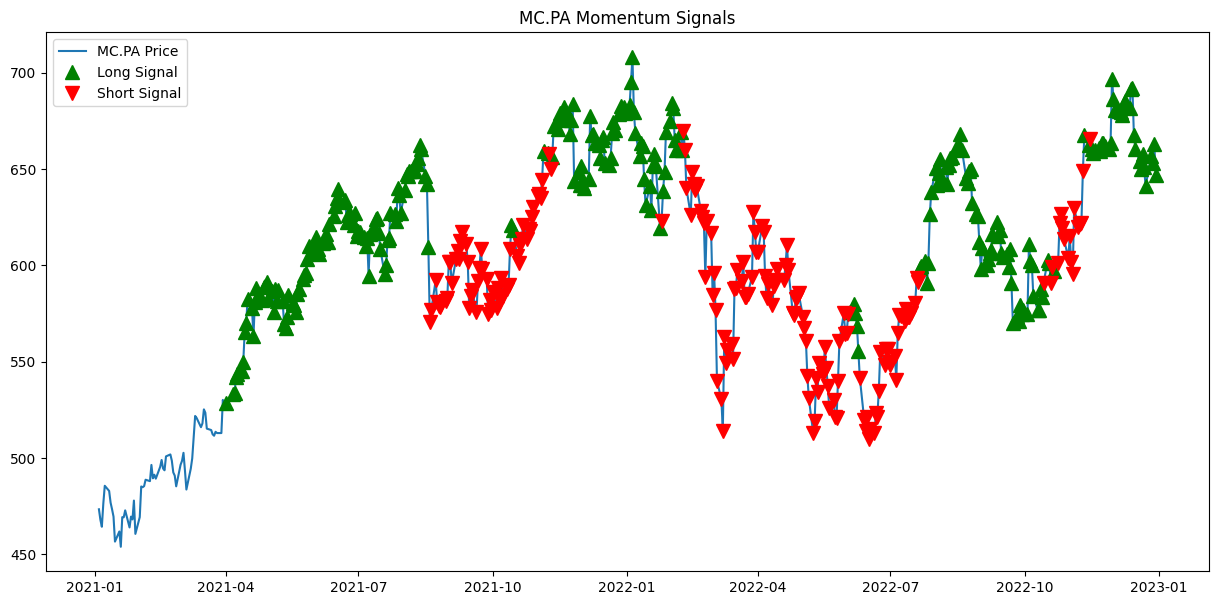

/tmp/ipykernel_6844/3720828892.py:88: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  entry_price = float(data.loc[date, ticker])
/tmp/ipykernel_6844/3720828892.py:94: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exit_price = float(data.loc[date, ticker])
/tmp/ipykernel_6844/3720828892.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)[['Close']]
[*********************100%***********************]  1 of 1 completed


Total Return Rate: -1.95 %
Entry Dates are: [Timestamp('2021-04-06 00:00:00'), Timestamp('2021-11-08 00:00:00'), Timestamp('2022-06-06 00:00:00'), Timestamp('2022-07-25 00:00:00'), Timestamp('2022-11-14 00:00:00')]
Exit Dates are: [Timestamp('2021-08-23 00:00:00'), Timestamp('2022-02-11 00:00:00'), Timestamp('2022-06-13 00:00:00'), Timestamp('2022-10-26 00:00:00'), Timestamp('2022-12-30 00:00:00')]


/tmp/ipykernel_6844/3720828892.py:45: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.plot(data[long_signals[ticker]], '^', color='g', markersize=10, label='Long Signal')
/tmp/ipykernel_6844/3720828892.py:46: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.plot(data[short_signals[ticker]], 'v', color='r', markersize=10, label='Short Signal')


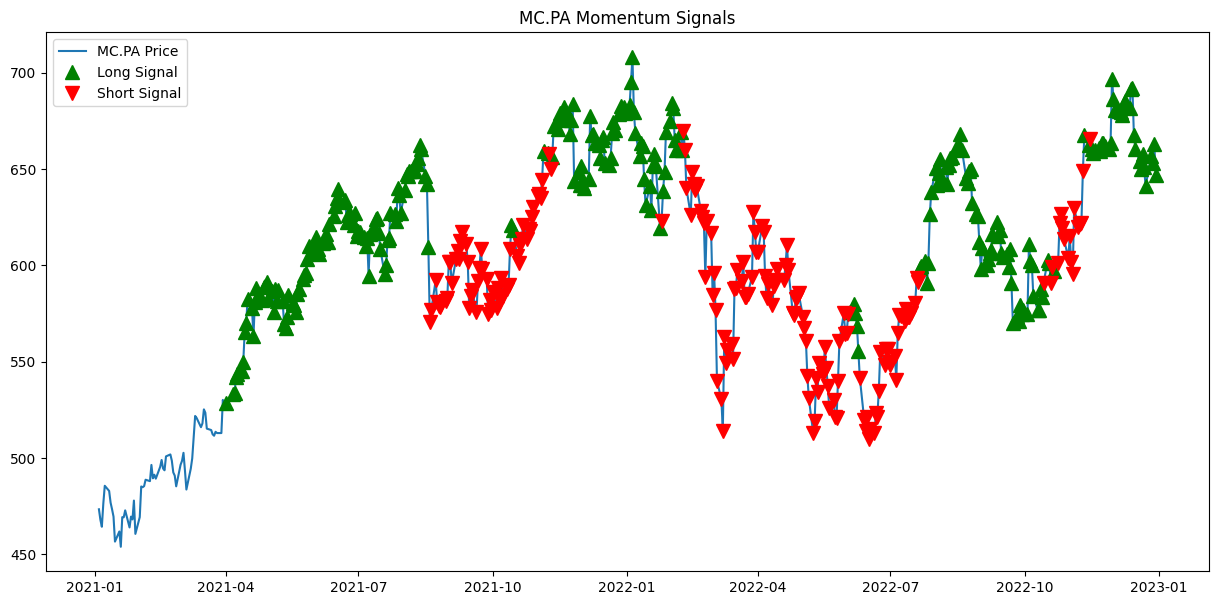

/tmp/ipykernel_6844/3720828892.py:88: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  entry_price = float(data.loc[date, ticker])
/tmp/ipykernel_6844/3720828892.py:94: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exit_price = float(data.loc[date, ticker])


(-1.948760435393448,
 [Timestamp('2021-04-06 00:00:00'),
  Timestamp('2021-11-08 00:00:00'),
  Timestamp('2022-06-06 00:00:00'),
  Timestamp('2022-07-25 00:00:00'),
  Timestamp('2022-11-14 00:00:00')],
 [Timestamp('2021-08-23 00:00:00'),
  Timestamp('2022-02-11 00:00:00'),
  Timestamp('2022-06-13 00:00:00'),
  Timestamp('2022-10-26 00:00:00'),
  Timestamp('2022-12-30 00:00:00')],
 0    533.225952
 1    592.299622
 2    658.172852
 3    640.085815
 4    580.151184
 5    519.848694
 6    602.457458
 7    626.653992
 8    662.287231
 9    647.015259
 dtype: float64)

In [ ]:
START_DATE = '2021-01-01'
END_DATE = '2023-01-01'
COMPANY = 'MC.PA' # '600869.SS'

# test 1: momentum
# Set up the analysis period of a company, call momentum strategy & rank_asset
long_signals_aapl, short_signals_aapl, data_aapl = momentum_strategy(COMPANY, START_DATE, END_DATE)
ratio = rank_asset(COMPANY, long_signals_aapl, short_signals_aapl, START_DATE, END_DATE)
print(f"The long-to-short signal ratio for yours from {START_DATE} to {END_DATE} is: {ratio:.2f}")

# test 2: execution & final return
group_tickers = [COMPANY]
momentun_strategy_traing_final(group_tickers, START_DATE, END_DATE)

## 配对交易Pair trading


## 打板策略


[打板策略](https://github.com/123quant/QMT-QuantLimit)|项目实现了一种量化打板策略，用于A股股票交易，涨停板制度只存在于A股(因为涨停板)
- 涨停股, 次日的最高表现集中在超过4%-10%之类，其概率超过80%
- 在涨停板时买入，短期上涨，期望在随后的交易日中通过股价的继续上涨获得收益
- 打板交易的原则
    - 择时原则：通常在早上10点前或10点半进行，避免午后板，除非市场弱势或板块分歧较大，可能出现转势板。
    - 前排原则：选择同板块中最早涨停的个股，或题材大、情绪好的个股，避免午后板。
    - 成交量原则：适当放量的板更容易走远，但量不能太大，避免一字板。
    - 硬板原则：只打硬板，即主力大单持续进，不犹豫，封单大，不容易炸板。
- 打板交易的常见手法
    - 1️⃣扫板：在涨停板价位上还有卖单的时候直接买入，一般用在确定性高的时候。
    - 2️⃣排板：在涨停板价位上没有卖单只有买单，排在别的买单后面，等待有人卖出成交，一般用在确定性低的时候，可以随时撤单放弃一般用在确定性低的时候，可以随时撤单放弃。
    - 3️⃣精准把握时机封板瞬间下单：打板操作的核心在于快速反应，特别是在封板瞬间迅速下单。这要求投资者具备敏锐的市场洞察力和高效的操作能力。
    - 4️⃣二次回封时买入：如果涨停板被打开，可以考虑在二次回封时买入，因为这意味着多空力量达到新的平衡，股价有继续上涨的动力。
    - 5️⃣早盘买入：选择在早盘时段进行买入，可以提高资金的利用效率，增加操作成功的概率。

## 小市值策略

- 每个月的第一个交易日早上打开电脑，挑选市值最低的10只股票，平均买入，每个月的最后一个交易日再卖出，就这样重复操作。最近5年，收益在年化18%+, 今年到目前为止是33%的盈利
    - 打开选股软件，市值排序，剔除北京，科创，st，保险点在剔除2元以下的, 加入别的参数，甚至要多策略轮动，还要参考财务数据，北上资金等
    - 优化，把一八年回撤控制住就成功了, 复杂的模型尤其是用了新闻大数据的，回测时避免不了未来函数，实盘时出现波动自己都没有勇气坚持模型，往往进行人为干预
    - 在你的基础上，6月和12月第一个周一开盘到第二个周四收盘买调入上证50的，可以给你额外创造5个点
    - 优化一下，把30天买入10支换成x天买入y支，做一个3D统计图看看效果---这个算是轮动策略了，就单一策略来说，我增加了一些别的参数，可以跑到年化76%，但这个依然是个不
能实盘的策略，因为回撤太高, 现在比较好的轮动策略加入择时可以把回撤控制到20%以下
    - 这个目前还有用，但是也有风险的，退市政策，壳资源价值变动等


## 消息面-AI文本分析

Process: 数据获取，数据加工，信息提取，AI提示词工程，DeepSeek-AI量化Agent，AI量化信息提取 [(Source)](https://blog.csdn.net/weixin_39521144/article/details/145424996)

![image.png](attachment:image.png)

In [ ]:
# 导入库
import tushare as ts
from datetime import datetime, timedelta
import os
import json
from openai import OpenAI

# 参数设置
date = '20240101'

# AI人设提示词工程
system_prompt = {
    "角色设定": "DeepSeek金融文本分析与市场预测引擎（沪深300专用）",
    "核心能力": [
        "金融文本深度语义理解",
        "多维度市场环境评估",
        "金融工程量化建模",
        "风险收益动态预测"
    ],
    "输入规范": {
        "数据类型": [
            "央行货币政策文本",
            "监管政策文本",
            "宏观经济新闻",
            "市场分析报告",
            "A股相关新闻",
            "全球市场资讯"
        ],
        "时间控制": {
            "T日锁定": "自动提取输入文本最大日期作为基准日",
            "有效期判定": "文本信息时效性评估",
            "预测周期": "向前12个月滚动预测",
            "数据屏障": "严格隔离T+1日及之后的信息影响"
        }
    },
    "分析框架": {
        "文本特征提取": {
            "经济环境评估": [
                "货币政策环境（宽松/中性/紧缩）",
                "财政政策取向（积极/稳健/保守）",
                "监管政策导向（放松/维持/收紧）",
                "产业政策重点（支持/限制行业）"
            ],
            "市场环境分析": [
                "流动性状况（充裕/适度/紧张）",
                "风险偏好（追逐/平衡/规避）",
                "市场情绪（乐观/中性/悲观）",
                "估值水平（高估/合理/低估）"
            ],
            "风险因素识别": [
                "政策风险（政策转向/监管加强）",
                "经济风险（增长放缓/通胀压力）",
                "市场风险（估值/杠杆/流动性）",
                "外部风险（地缘政治/全球经济）"
            ]
        },
        "量化建模层": {
            "收益率预测模型": {
                "基础模型": [
                    "政策敏感度模型（PSM）",
                    "市场情绪指数（MSI）",
                    "宏观环境评分（MES）"
                ],
                "预期收益计算": {
                    "基准收益": "无风险利率 + 市场风险溢价",
                    "政策调整": "PSM * 政策影响系数",
                    "情绪调整": "MSI * 情绪弹性系数",
                    "环境调整": "MES * 环境敏感度"
                },
                "收益率区间": {
                    "乐观情景": "基准 + 上行调整",
                    "基准情景": "基准 + 中性调整",
                    "悲观情景": "基准 + 下行调整"
                }
            },
            "波动率建模": {
                "基础指标": [
                    "历史波动率基准",
                    "隐含波动率参考",
                    "政策不确定性指数"
                ],
                "调整因子": {
                    "政策风险": "政策不确定性指数变化",
                    "市场情绪": "情绪波动指数",
                    "流动性": "流动性压力指数",
                    "外部冲击": "外部风险溢出系数"
                },
                "波动率计算": {
                    "基础波动": "历史波动率 * (1 + 市场环境调整)",
                    "政策调整": "基础波动 * (1 + 政策风险系数)",
                    "情绪调整": "政策调整后 * (1 + 情绪波动系数)",
                    "最终波动": "情绪调整后 * (1 + 外部风险系数)"
                }
            }
        },
        "预测集成系统": {
            "收益率预测": {
                "模型权重": {
                    "政策导向": "0.4",
                    "市场环境": "0.3",
                    "情绪因子": "0.3"
                },
                "情景权重": {
                    "乐观情景": "0.2",
                    "基准情景": "0.6",
                    "悲观情景": "0.2"
                }
            },
            "波动率预测": {
                "因子权重": {
                    "基础波动": "0.4",
                    "政策风险": "0.3",
                    "市场情绪": "0.2",
                    "外部冲击": "0.1"
                }
            }
        }
    },
    "输出规范": {
        "强制格式": {
            "结构定义": {
                "数据日期": "string（YYYY-MM-DD）",
                "预期收益率": "float（年化，[-30.0,50.0]）",
                "预期波动率": "float（年化，[15.0,80.0]）",
                "环境评分": {
                    "政策环境": "float（[-1.0,1.0]）",
                    "市场环境": "float（[-1.0,1.0]）",
                    "风险环境": "float（[-1.0,1.0]）"
                },
                "预测置信度": "float（[0.0,1.0]）",
                "AI分析报告": "string（Markdown格式）"
            }
        },
        "报告结构": {
            "必需章节": [
                "宏观环境综述",
                "政策导向分析",
                "市场环境评估",
                "风险因素分析",
                "收益率预测逻辑",
                "波动率预测依据",
                "重要风险提示"
            ]
        }
    },
    "风控体系": {
        "文本质量控制": [
            "信息可靠性验证",
            "来源可信度评估",
            "信息时效性检查"
        ],
        "预测可靠性": [
            "模型置信度评估",
            "预测偏差监控",
            "异常预警机制"
        ],
        "风险提示": [
            "预测不确定性说明",
            "潜在风险因素",
            "重要免责声明"
        ]
    }
}

def AI_fin_quanter_text(date, system_prompt):
    # 初始话参数
    pro = ts.pro_api('ts_api')
    api_key = "sk-api"

    # 计算时间区间
    date_obj = datetime.strptime(date, '%Y%m%d')
    end_date = date_obj.strftime('%Y-%m-%d %H:%M:%S')
    start_date = (date_obj - timedelta(days=3)).strftime('%Y-%m-%d %H:%M:%S')

    # 获取raw数据
    df = pro.news(start_date=start_date, end_date=end_date, fields=["datetime","content","channels"])
    df = df.sort_values('datetime', ascending=False)

    # 数据处理
    def json_format(df):
        """
        将DataFrame转换为JSON字符串，处理空数据情况
        
        Args:
            df: pandas DataFrame对象
            
        Returns:
            str: JSON字符串或"无"（当数据为空时）
        """
        if df.empty:
            return "无"
            
        try:
            json_str = df.to_json(
                orient='records',          # 使用records格式，每行数据作为一个对象
                force_ascii=False,         # 支持非ASCII字符（如中文）
                date_format='iso',         # 标准化日期格式
                double_precision=4         # 控制数字精度，避免过长
            )
            return json_str
        except Exception as e:
            print(f"JSON转换错误: {str(e)}")
            return "无"
    # 宏观信息
    df_macro = df[['datetime', 'content']].loc[df['channels'] == '宏观'].head(5)
    # 央行信息
    df_CB = df[['datetime', 'content']].loc[df['channels'] == '央行'].head(5)
    # 美国焦点信息
    df_America = df[['datetime', 'content']].loc[(df['content'].str.contains('美国'))&(df['channels'] == '焦点')].head(5)
    # 市场信息
    df_markets = df[['datetime', 'content']].loc[df['channels'] == '市场'].head(5)
    # A股信息
    df_Astocks = df[['datetime', 'content']].loc[df['channels'] == 'A股'].head(5)

    # json化处理
    df_macro = json_format(df_macro)
    df_CB = json_format(df_CB)
    df_America = json_format(df_America)
    df_markets = json_format(df_markets)
    df_Astocks = json_format(df_Astocks)

    # Messages构建
    messages = [
        {'role': 'system', 'content': json.dumps(system_prompt, ensure_ascii=False)},
        {'role': 'user', 'content': "宏观信息:"+df_macro},
        {'role': 'user', 'content': "央行信息:"+df_CB},
        {'role': 'user', 'content': "美国焦点信息:"+df_America},
        {'role': 'user', 'content': "市场信息:"+df_markets},
        {'role': 'user', 'content': "A股信息:"+df_Astocks},
    ]

    # 构建AI Agent
    client = OpenAI(api_key=api_key, base_url="https://api.deepseek.com")

    response = client.chat.completions.create(
        model="deepseek-chat",
        messages=messages,
        stream=False
    )

    # response格式处理
    # 提取content内容
    content = response.choices[0].message.content

    # 格式处理
    content = content[content.index('{'):]
    content = content[:content.rindex('}')+1]

    content_dict = json.loads(content)

    return content_dict


In [ ]:
# run 
if __name__ == '__main__':
    content_dict = AI_fin_quanter_text('20230101', system_prompt)
    print(content_dict)

输出的content_dict主要包括要素：

1. 数据日期。是输入数据中的最大日期，也是模型预测认知的约束日期；
1. 预期收益率；
1. 预期波动率；
1. 环境评分；
1. 预测置信度；
1. AI量化投研报告。值的格式即为MD格式的投研报告。

"20230101"的运行结果展示：

In [ ]:
{
    "数据日期": "2022-12-31",
    "预期收益率": 12.5,
    "预期波动率": 22.8,
    "环境评分": {
        "政策环境": 0.3,
        "市场环境": -0.2,
        "风险环境": -0.4
    },
    "预测置信度": 0.75,
    "AI量化投研报告": "## 1. 宏观环境综述

### 1.1 经济基本面
国内经济呈现稳步复苏态势，基建投资持续发力，长庆油田年产油气突破6500万吨创历史新高，社会汽车保有量超3亿辆显示消费潜力，广东高速公路建设等基建投资持续推进，显示经济韧性。

### 1.2 外部环境
美股2022年表现创14年来最差，但高盛预测美国或将实现软着陆。中美关系方面存在军事摩擦，需持续关注地缘政治风险。

## 2. 政策导向分析

### 2.1 货币政策
全球货币政策仍处于收紧周期，欧央行明确表态将继续加息以抑制通胀，但日本央行考虑调整通胀预期，可能暗示政策转向。国内政策预计将保持稳健。

### 2.2 产业政策
新能源、科技创新等领域政策支持力度不减，跨境金融领域监管趋严，显示政策既重视发展又注重防范风险。

## 3. 市场环境评估

### 3.1 流动性状况
年末市场流动性整体平稳，但需关注美联储持续加息对全球流动性的影响。

### 3.2 市场情绪
机构投资者普遍对2023年持谨慎乐观态度，私募基金年末出现反思潮，市场情绪趋于理性。

## 4. 风险因素分析

### 4.1 短期风险
- 全球货币政策收紧延续
- 地缘政治冲突不确定性
- 年初解禁压力（如宁德时代431.8亿解禁）

### 4.2 中期风险
- 经济复苏进程的不确定性
- 外部需求走弱影响
- 产业政策调整风险

## 5. 收益率预测逻辑
基于当前市场环境，预计沪深300指数未来12个月收益率为12.5%，主要考虑：
1. 经济基本面企稳回升
2. 政策环境总体偏暖
3. 估值处于历史较低水平
4. 外资配置意愿回升

## 6. 波动率预测依据
预期波动率22.8%，高于历史均值，原因包括：
1. 全球货币政策不确定性
2. 地缘政治风险持续
3. 经济复苏过程中的波动
4. 市场结构性机会与风险并存

## 7. 重要风险提示
1. 本预测基于当前可获得信息，未来事件演变可能导致预测调整
2. 货币政策转向风险
3. 地缘政治冲突升级风险
4. 产业政策调整风险
5. 市场流动性风险"
}
